In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
import joblib

In [ ]:
import os
import getpass
os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("API Key: ")
!pip install -q kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
kaggle = KaggleApi()
kaggle.authenticate()
dataset = "uciml/adult-census-income"
kaggle.dataset_download_files(
    dataset=dataset,
    path="./",
    unzip=True
)
print("Dataset download is successful.")

Username: varun22
API Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income
Dataset download is successful.


In [ ]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape


(32561, 15)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#DATASET CLEANING
df.replace(" ?", np.nan, inplace=True)
df.dropna(inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

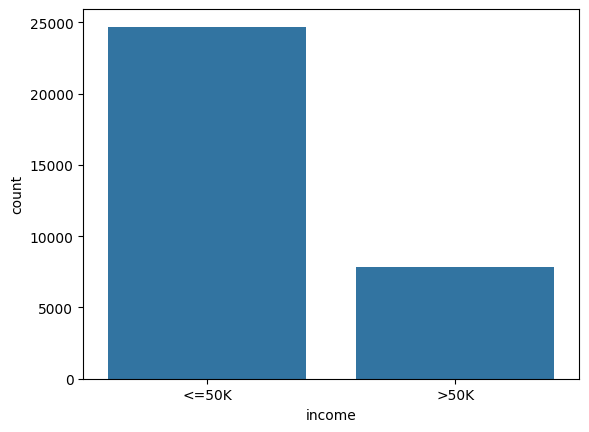

In [ ]:
#EDA
sns.countplot(x='income', data=df)
plt.show()

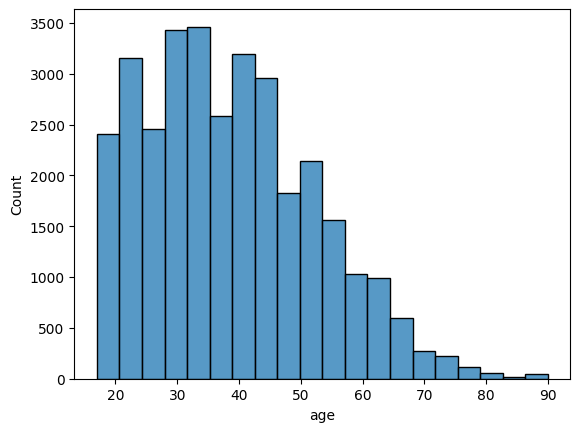

In [ ]:
sns.histplot(df['age'], bins=20)
plt.show()

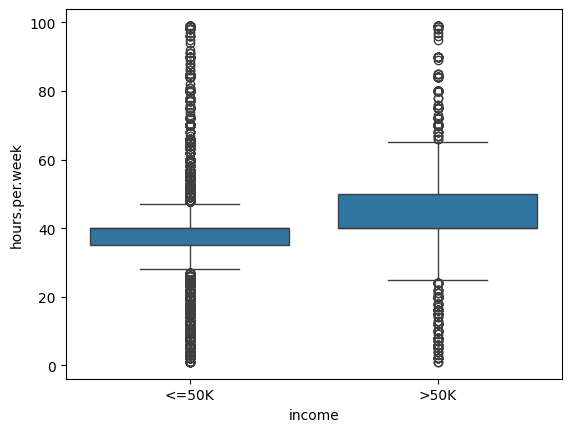

In [ ]:
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.show()

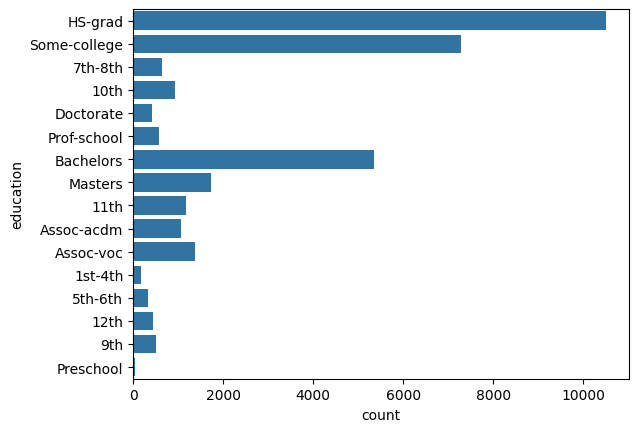

In [ ]:
sns.countplot(y='education', data=df)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes(include='object'):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [ ]:
#Splitting Features and Target
X = df.drop("income", axis=1)
y = df["income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Training Model
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Prediction
new_person = pd.DataFrame({
    'age': [35],
    'workclass': ['Private'],
    'fnlwgt': [120000],
    'education': ['Bachelors'],
    'education.num': [13],
    'marital.status': ['Never-married'],
    'occupation': ['Prof-specialty'],
    'relationship': ['Not-in-family'],
    'race': ['White'],
    'sex': ['Male'], # Changed 'gender' to 'sex' to match original dataset and encoders
    'capital.gain': [0],
    'capital.loss': [0],
    'hours.per.week': [40],
    'native.country': ['United-States']
})
categorical_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex', # Changed 'gender' to 'sex'
    'native.country'
] # This list should only contain actual categorical features that were label-encoded

for col in categorical_cols:
    new_person[col] = encoders[col].transform(new_person[col])
new_person_scaled = scaler.transform(new_person)
prediction = rf.predict(new_person_scaled)
if prediction[0] == 1:
    print("Predicted Income: >50K")
else:
    print("Predicted Income: <=50K")
print("----- New Person Details -----")
print(new_person)

print("\nPredicted Annual Income:")

if prediction[0] == 1:
    print("Income > $50K")
else:
    print("Income <= $50K")

Predicted Income: <=50K
----- New Person Details -----
   age  workclass  fnlwgt  education  education.num  marital.status  \
0   35          4  120000          9             13               4   

   occupation  relationship  race  sex  capital.gain  capital.loss  \
0          10             1     4    1             0             0   

   hours.per.week  native.country  
0              40              39  

Predicted Annual Income:
Income <= $50K


In [ ]:
prediction = rf.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
print(accuracy)

0.8603257529194838


In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4988
           1       0.73      0.63      0.68      1520

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.80      6508
weighted avg       0.86      0.86      0.86      6508



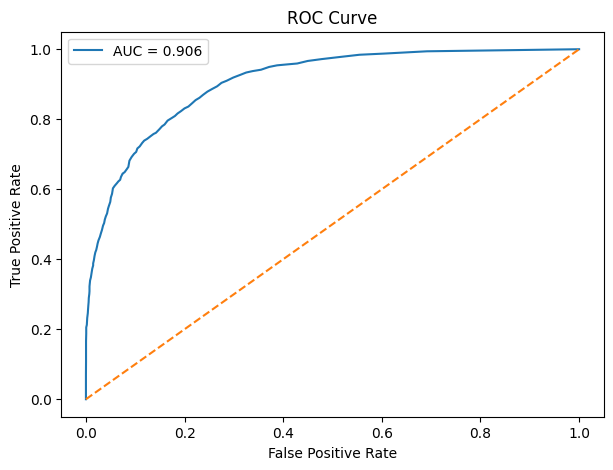

AUC Score: 0.9060309875279619


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc)

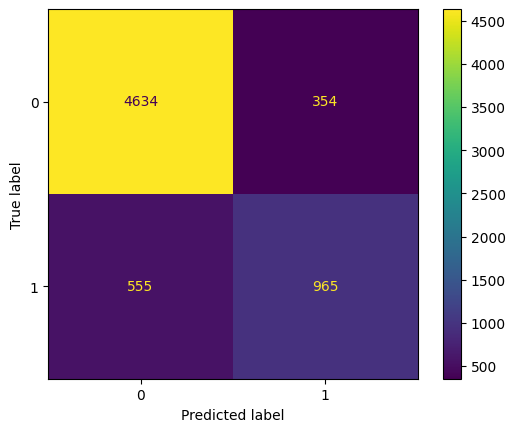

In [ ]:
cm = confusion_matrix(y_test, prediction)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
params = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Parameters:")
print(grid.best_params_)
print("Best Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Accuracy:
0.8647662141111839


In [ ]:
joblib.dump(rf, "income_classifier.pkl")

['income_classifier.pkl']

In [ ]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
